# Camada GOLD - Analise de Viagens (Portal da Transparencia)

O notebook lê a camada **SILVER** e responde as perguntas de negocio do projeto. Para cada uma: a consulta SQL, a tabela com o resultado e um gráfico.

**Perguntas respondidas (Parte 1 - direto da Silver):**
1. Os 5 órgãos com maior custo total.
2. Os 3 destinos com maior custo médio por viagem.
3. A viagem de maior duracão e seu custo total.

**Camada Gold agregada:**
- `gold_pagamentos_por_orgao` - junta `silver_viagem` com `silver_pagamento`
  (JOIN + GROUP BY) e soma o valor pago por órgao superior, criada como
  **tabela** e como **VIEW**.

**Perguntas respondidas (Parte 2 - usando a Gold e mais agregações):**

4. Qual órgao pagou mais no total (usa `gold_pagamentos_por_orgao`).
5. Qual tipo de pagamento tem o maior valor médio.
6. Qual meio de transporte é mais usado nos trechos.
7. Qual UF de destino aparece em mais trechos.

## Conexao com o banco
Reaproveita o `banco.py` de `../scripts/`. As credenciais ficam no `.env`
(na raiz do projeto). Este notebook fica em `notebooks/`, entao usamos
`sys.path.append('../scripts')` para o Python encontrar `banco.py` e
`config.py` ao rodar a partir daqui.

In [3]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('../scripts')
import banco

conexao = banco.conectar()

PASTA_OUTPUTS = '../outputs'
os.makedirs(PASTA_OUTPUTS, exist_ok=True)

def consultar(sql):
    """Roda um SELECT e devolve o resultado como DataFrame do pandas."""
    return pd.read_sql(sql, conexao)

def reais(valor):
    """Formata um numero como moeda brasileira: 1234.5 -> 'R$ 1.234,50'."""
    texto = f'{valor:,.2f}'
    return 'R$ ' + texto.replace(',', 'X').replace('.', ',').replace('X', '.')

def salvar_grafico(nome_arquivo):
    """Exporta o grafico atual como PNG dentro de outputs/ (na raiz do projeto)."""
    caminho = os.path.join(PASTA_OUTPUTS, nome_arquivo)
    plt.savefig(caminho, dpi=150, bbox_inches='tight')

print('Conectado ao MySQL com sucesso.')

Conectado ao MySQL com sucesso.


## Pergunta 1 - Os 5 órgãos com maior custo total
Agrupa `silver_viagem` por `nome_orgao_superior` e soma `valor_total`
(coluna já calculada na Fase 2: diarias + passagens + outros - devolução).

In [4]:
sql_q1 = '''
SELECT nome_orgao_superior AS orgao,
       SUM(valor_total)    AS custo_total,
       COUNT(*)            AS qtd_viagens
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
'''

q1 = consultar(sql_q1)
q1['custo_total_formatado'] = q1['custo_total'].apply(reais)
q1

/tmp/ipykernel_11442/2586381946.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,orgao,custo_total,qtd_viagens,custo_total_formatado
0,Ministério da Justiça e Segurança Pública,4.869331e+08,75742,"R$ 486.933.121,65"
1,Ministério da Defesa,1.560703e+08,61912,"R$ 156.070.304,49"
2,Ministério da Educação,1.112913e+08,65295,"R$ 111.291.349,34"
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07,19413,"R$ 49.697.710,16"
4,Ministério da Previdência Social,4.041731e+07,8190,"R$ 40.417.309,06"


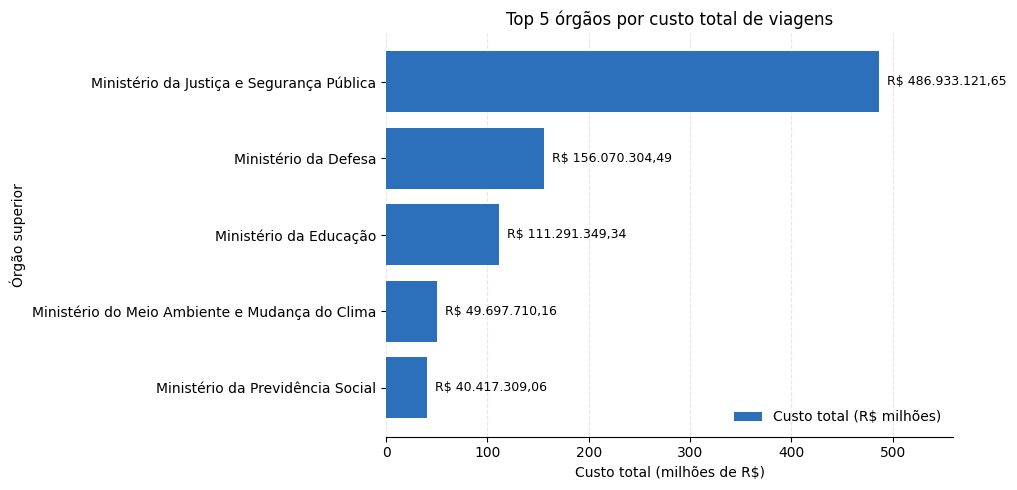

In [5]:
custo_total_mi = q1['custo_total'] / 1_000_000  # em milhoes, so para caber no eixo

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(q1['orgao'], custo_total_mi, color='#2c6fbb', label='Custo total (R$ milhões)')
ax.invert_yaxis()  # maior no topo
ax.set_title('Top 5 órgãos por custo total de viagens')
ax.set_xlabel('Custo total (milhões de R$)')
ax.set_ylabel('Órgão superior')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.set_xlim(0, custo_total_mi.max()*1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
for i, valor in enumerate(q1['custo_total']):
    ax.text(valor / 1_000_000, i, '  ' + reais(valor), va='center', fontsize=9)
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
salvar_grafico('pergunta1_top_orgaos_custo_total.png')
plt.show()

## Pergunta 2 - Os 3 destinos com maior custo médio por viagem
Agrupa por `destinos` (texto como veio da Raw) e calcula a média de
`valor_total`. Um destino usado poucas vezes pode "vencer" só por causa
de 1 ou 2 viagens caras, sem ser um padrão real - por isso 
`HAVING COUNT(*) >= 30` (pelo menos 30 viagens no grupo) para o resultado ser representativo.

In [6]:
sql_q2 = '''
SELECT destinos          AS destino,
       AVG(valor_total)  AS custo_medio,
       COUNT(*)          AS qtd_viagens
FROM silver_viagem
WHERE destinos <> ''
GROUP BY destinos
HAVING COUNT(*) >= 30
ORDER BY custo_medio DESC
LIMIT 3;
'''

q2 = consultar(sql_q2)
q2['custo_medio_formatado'] = q2['custo_medio'].apply(reais)
q2

/tmp/ipykernel_11442/2586381946.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino,custo_medio,qtd_viagens,custo_medio_formatado
0,"Brasília/DF, Brasília/DF, Brasília/DF, Brasíli...",105470.366044,91,"R$ 105.470,37"
1,"Brasília/DF, Brasília/DF, Brasília/DF",100317.261023,88,"R$ 100.317,26"
2,"Brasília/DF, Brasília/DF, Brasília/DF, Brasíli...",97736.688085,47,"R$ 97.736,69"


/tmp/ipykernel_11442/3098609271.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', frameon=False)


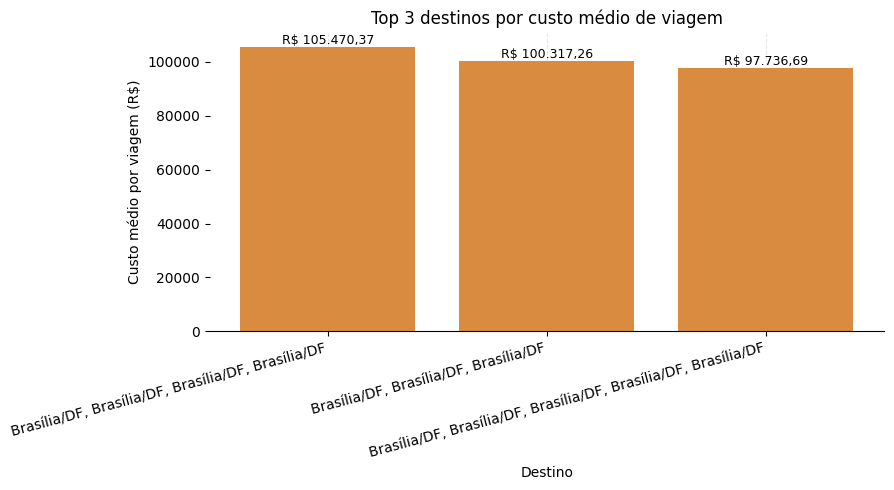

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(q2['destino'], q2['custo_medio'], color='#D98C3F')
ax.set_title('Top 3 destinos por custo médio de viagem')
ax.set_xlabel('Destino')
ax.set_ylabel('Custo médio por viagem (R$)')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.xticks(rotation=15, ha='right')
for i, valor in enumerate(q2['custo_medio']):
    ax.text(i, valor, reais(valor), ha='center', va='bottom', fontsize=9)
ax.legend(loc='upper right', frameon=False)
plt.tight_layout()
salvar_grafico('pergunta2_top_destinos_custo_medio.png')
plt.show()

## Pergunta 3 - A viagem de maior duração e seu custo total
A coluna `duracao_dias` ja foi calculada na Fase 2 (`DATEDIFF(data_fim, data_inicio)`).
Ordena por ela e pega a primeira.

**Observação sobre o resultado:** A viagem retornada tem custo total R$ 0,00 possivelmente
porque, dentro do recorte de 6 meses analisado, ainda não há nenhum
pagamento ou passagem lançado para ela. O gráfico não foi gerado, já que não há dados de custos. 

In [8]:
sql_q3 = '''
SELECT id_viagem, nome_orgao_superior, nome_viajante, destinos,
       data_inicio, data_fim, duracao_dias,
       valor_diarias, valor_passagens, valor_outros_gastos, valor_devolucao,
       valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC
LIMIT 1;
'''

q3 = consultar(sql_q3)
viagem = q3.iloc[0]

print('VIAGEM DE MAIOR DURACAO')
print('-' * 40)
print('ID da viagem :', viagem['id_viagem'])
print('Orgao        :', viagem['nome_orgao_superior'])
print('Viajante     :', viagem['nome_viajante'])
print('Destino(s)   :', viagem['destinos'])
print('Inicio       :', viagem['data_inicio'])
print('Fim          :', viagem['data_fim'])
print('Duracao      :', int(viagem['duracao_dias']), 'dias')
print('Custo total  :', reais(viagem['valor_total']))
q3

/tmp/ipykernel_11442/2586381946.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


VIAGEM DE MAIOR DURACAO
----------------------------------------
ID da viagem : 0000000000020699856
Orgao        : Ministério da Previdência Social
Viajante     : LUISANGELA CORREA FRANCO DE FARIA
Destino(s)   : Mogi Mirim/SP
Inicio       : 2025-01-13
Fim          : 2026-01-31
Duracao      : 383 dias
Custo total  : R$ 0,00


,id_viagem,nome_orgao_superior,nome_viajante,destinos,data_inicio,data_fim,duracao_dias,valor_diarias,valor_passagens,valor_outros_gastos,valor_devolucao,valor_total
0,0000000000020699856,Ministério da Previdência Social,LUISANGELA CORREA FRANCO DE FARIA,Mogi Mirim/SP,2025-01-13,2026-01-31,383,0.0,0.0,0.0,0.0,0.0


**Gráfico da Pergunta 3 - comparação das viagens mais longas com custo registrado:**
como a viagem de maior duração (acima) ainda não tem nenhum custo lançado, um gráfico 
só dela não teria o que mostrar. Para ilustrar o custo de viagens longas, 
foi feita uma comparação das **3 viagens de maior duração que ja tem valor_total > 0**.

In [12]:
sql_q3b = '''
SELECT id_viagem, duracao_dias, valor_total
FROM silver_viagem
WHERE valor_total > 0
ORDER BY duracao_dias DESC
LIMIT 3;
'''

q3b = consultar(sql_q3b)
q3b['valor_total_formatado'] = q3b['valor_total'].apply(reais)

# monta o rotulo de cada barra do grafico, so com a duracao em dias
rotulos = []
for i in range(len(q3b)):
    dias = int(q3b['duracao_dias'].iloc[i])
    rotulo = f"{dias} dias"
    rotulos.append(rotulo)

q3b['rotulo'] = rotulos
q3b

/tmp/ipykernel_11442/2586381946.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,id_viagem,duracao_dias,valor_total,valor_total_formatado,rotulo
0,0000000000020793594,378,120650.0,"R$ 120.650,00",378 dias
1,0000000000020793492,369,113382.5,"R$ 113.382,50",369 dias
2,0000000000020592696,366,159044.9,"R$ 159.044,90",366 dias


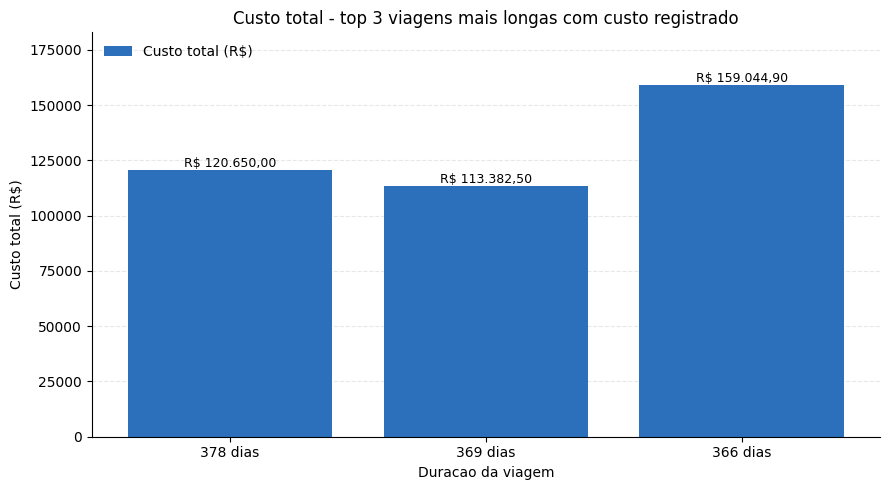

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(q3b['rotulo'], q3b['valor_total'], color='#2c6fbb', label='Custo total (R$)')
ax.set_title('Custo total - top 3 viagens mais longas com custo registrado')
ax.set_xlabel('Duracao da viagem')
ax.set_ylabel('Custo total (R$)')
ax.set_ylim(top=q3b['valor_total'].max() * 1.15)  # folga para o rotulo nao colidir com a legenda
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, valor in enumerate(q3b['valor_total']):
    ax.text(i, valor, reais(valor), ha='center', va='bottom', fontsize=9)
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
salvar_grafico('pergunta3_comparacao_viagens_longas.png')
plt.show()

---

## Camada Gold agregada - `gold_pagamentos_por_orgao`

Junta `silver_viagem` com `silver_pagamento` pela chave `id_viagem`
(`JOIN`) e soma o valor pago por `nome_orgao_superior` (`GROUP BY`).

**Por que o JOIN é obrigatório:** `silver_pagamento` não tem a coluna
`nome_orgao_superior`, só tem `nome_orgao_pagador` (a unidade que
processou o pagamento, ex.: "Comando da Aeronautica", "Receita Federal
do Brasil", "INSS"). Sem o JOIN, não é possível agrupar
corretamente por órgão superior, que é o que a pergunta pede.

Criada de **duas formas**: como **tabela** e como **VIEW**.

In [14]:
consulta_gold = '''
SELECT
    v.nome_orgao_superior      AS orgao,
    COUNT(p.id_pagamento)      AS qtd_pagamentos,
    SUM(p.valor)               AS total_pago
FROM silver_viagem AS v
JOIN silver_pagamento AS p ON p.id_viagem = v.id_viagem
GROUP BY v.nome_orgao_superior
'''

# 1) como TABELA
banco.executar(conexao, 'DROP TABLE IF EXISTS gold_pagamentos_por_orgao')
banco.executar(conexao, 'CREATE TABLE gold_pagamentos_por_orgao AS ' + consulta_gold)

# 2) como VIEW (mesma agregacao, sempre atualizada)
banco.executar(conexao, 'DROP VIEW IF EXISTS vw_gold_pagamentos_por_orgao')
banco.executar(conexao, 'CREATE VIEW vw_gold_pagamentos_por_orgao AS ' + consulta_gold)

gold = consultar('SELECT * FROM vw_gold_pagamentos_por_orgao ORDER BY total_pago DESC')
gold['total_pago_formatado'] = gold['total_pago'].apply(reais)
gold

/tmp/ipykernel_11442/2586381946.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,orgao,qtd_pagamentos,total_pago,total_pago_formatado
0,Ministério da Justiça e Segurança Pública,175814,4.888311e+08,"R$ 488.831.110,61"
1,Ministério da Defesa,93574,1.565498e+08,"R$ 156.549.767,91"
2,Ministério da Educação,93340,1.118974e+08,"R$ 111.897.434,35"
3,Ministério do Meio Ambiente e Mudança do Clima,26394,5.012304e+07,"R$ 50.123.043,80"
4,Ministério da Previdência Social,20106,4.065949e+07,"R$ 40.659.494,63"
5,Ministério da Saúde,18914,3.951792e+07,"R$ 39.517.918,03"
6,Ministério da Fazenda,23613,3.266602e+07,"R$ 32.666.017,41"
7,Ministério dos Povos Indígenas,10618,2.644114e+07,"R$ 26.441.142,20"
8,Ministério das Relações Exteriores,3757,2.572434e+07,"R$ 25.724.337,16"
9,Ministério do Desenvolvimento Agrário e Agricu...,13247,2.217168e+07,"R$ 22.171.683,47"


## Pergunta 4 - Qual orgao pagou mais no total
Responde direto consultando a camada Gold criada.

ORGAO QUE MAIS PAGOU NO TOTAL
----------------------------------------
Orgao       : Ministério da Justiça e Segurança Pública
Total pago  : R$ 488.831.110,61
Pagamentos  : 175814


/tmp/ipykernel_11442/3494318981.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right', frameon=False)


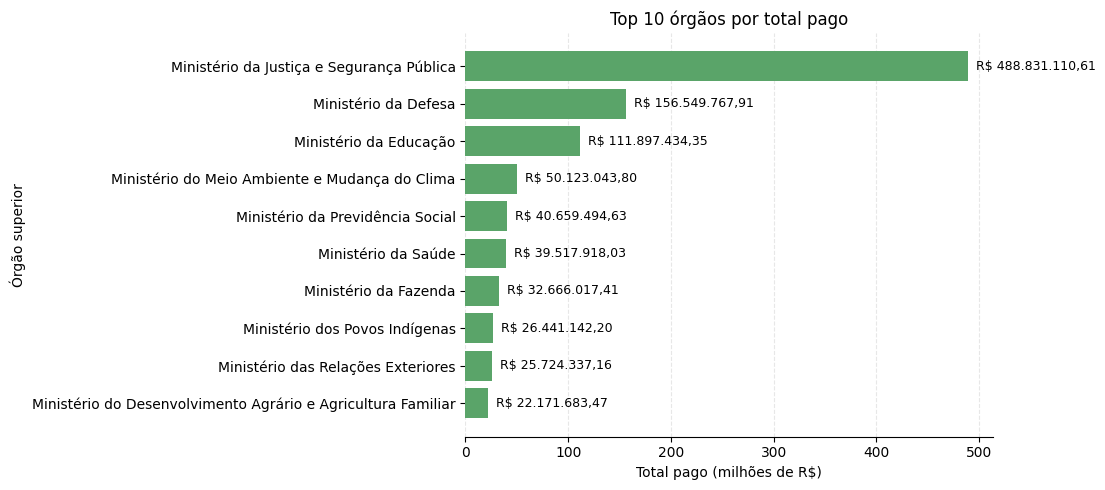

In [17]:
top_pagador = gold.iloc[0]
print('ORGAO QUE MAIS PAGOU NO TOTAL')
print('-' * 40)
print('Orgao       :', top_pagador['orgao'])
print('Total pago  :', reais(top_pagador['total_pago']))
print('Pagamentos  :', int(top_pagador['qtd_pagamentos']))

top10_gold = gold.head(10)
total_pago_mi = top10_gold['total_pago'] / 1_000_000  # em milhoes, so para caber no eixo

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top10_gold['orgao'], total_pago_mi, color='#5aa469')
ax.invert_yaxis()
ax.set_title('Top 10 órgãos por total pago')
ax.set_xlabel('Total pago (milhões de R$)')
ax.set_ylabel('Órgão superior')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
for i, valor in enumerate(top10_gold['total_pago']):
    ax.text(valor / 1_000_000, i, '  ' + reais(valor), va='center', fontsize=9)
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
salvar_grafico('pergunta4_top_orgaos_total_pago_gold.png')
plt.show()

## Pergunta 5 - Qual tipo de pagamento tem o maior valor medio
Agrupa `silver_pagamento` por `tipo_pagamento` e calcula a média de `valor`.

In [18]:
sql_q5 = '''
SELECT tipo_pagamento   AS tipo,
       AVG(valor)       AS valor_medio,
       COUNT(*)         AS qtd
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
'''

q5 = consultar(sql_q5)
q5['valor_medio_formatado'] = q5['valor_medio'].apply(reais)
q5

/tmp/ipykernel_11442/2586381946.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,tipo,valor_medio,qtd,valor_medio_formatado
0,DIÁRIAS,2078.280299,401463,"R$ 2.078,28"
1,PASSAGEM,1878.344393,188985,"R$ 1.878,34"
2,Serviço correlato: seguro,447.514653,4894,"R$ 447,51"
3,RESTITUIÇÃO,245.702610,11574,"R$ 245,70"


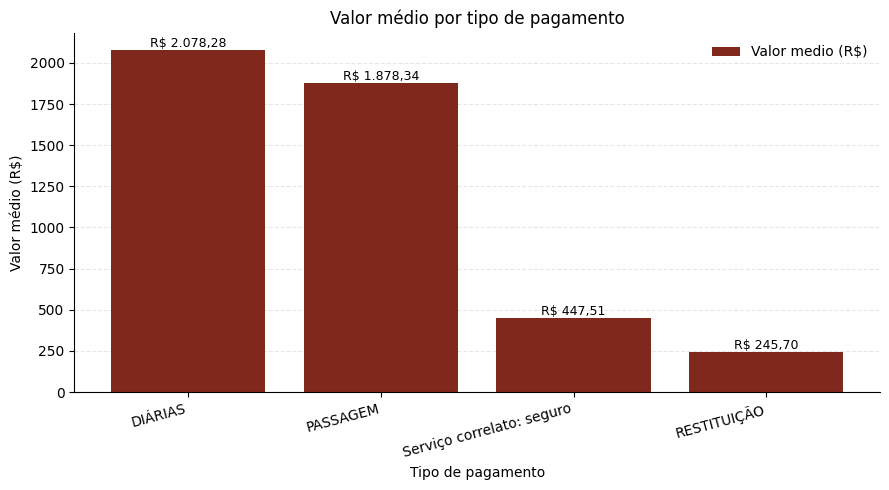

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(q5['tipo'], q5['valor_medio'], color="#81281c", label='Valor medio (R$)')
ax.set_title('Valor médio por tipo de pagamento')
ax.set_xlabel('Tipo de pagamento')
ax.set_ylabel('Valor médio (R$)')
plt.xticks(rotation=15, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, valor in enumerate(q5['valor_medio']):
    ax.text(i, valor, reais(valor), ha='center', va='bottom', fontsize=9)
ax.legend(loc='upper right', frameon=False)
plt.tight_layout()
salvar_grafico('pergunta5_valor_medio_por_tipo_pagamento.png')
plt.show()

## Pergunta 6 - Qual meio de transporte e mais usado nos trechos
Agrupa `silver_trecho` por `meio_transporte` e conta as ocorrências.

In [20]:
sql_q6 = '''
SELECT meio_transporte  AS meio,
       COUNT(*)         AS qtd_trechos
FROM silver_trecho
WHERE meio_transporte IS NOT NULL
GROUP BY meio_transporte
ORDER BY qtd_trechos DESC;
'''

q6 = consultar(sql_q6)
q6

/tmp/ipykernel_11442/2586381946.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,meio,qtd_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


/tmp/ipykernel_11442/3441964093.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', frameon=False)


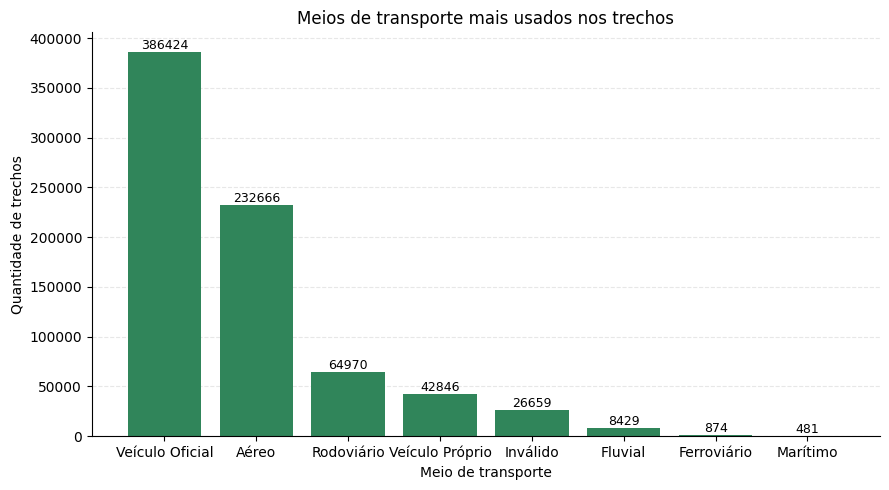

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(q6['meio'], q6['qtd_trechos'], color='#30855A')
ax.set_title('Meios de transporte mais usados nos trechos')
ax.set_xlabel('Meio de transporte')
ax.set_ylabel('Quantidade de trechos')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, valor in enumerate(q6['qtd_trechos']):
    ax.text(i, valor, str(valor), ha='center', va='bottom', fontsize=9)
ax.legend(loc='upper right', frameon=False)
plt.tight_layout()
salvar_grafico('pergunta6_meios_transporte.png')
plt.show()

## Pergunta 7 - Qual UF de destino aparece em mais trechos
Agrupa `silver_trecho` por `destino_uf` e conta as ocorrencias
(top 10 exibidas no grafico, para nao poluir com todas as UFs).

In [22]:
sql_q7 = '''
SELECT destino_uf       AS uf,
       COUNT(*)         AS qtd_trechos
FROM silver_trecho
WHERE destino_uf IS NOT NULL
GROUP BY destino_uf
ORDER BY qtd_trechos DESC
LIMIT 10;
'''

q7 = consultar(sql_q7)
q7

/tmp/ipykernel_11442/2586381946.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,uf,qtd_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


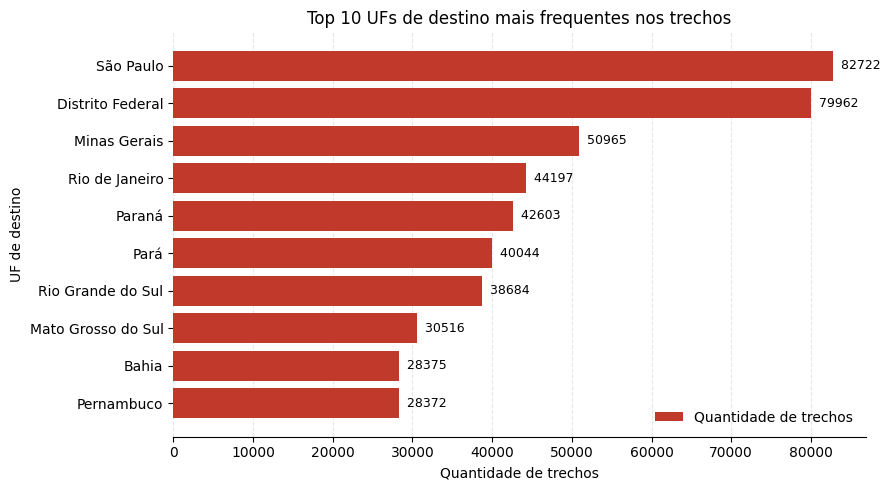

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(q7['uf'], q7['qtd_trechos'], color='#c0392b', label='Quantidade de trechos')
ax.invert_yaxis()
ax.set_title('Top 10 UFs de destino mais frequentes nos trechos')
ax.set_xlabel('Quantidade de trechos')
ax.set_ylabel('UF de destino')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
for i, valor in enumerate(q7['qtd_trechos']):
    ax.text(valor, i, '  ' + str(valor), va='center', fontsize=9)
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
salvar_grafico('pergunta7_top_ufs_destino_trechos.png')
plt.show()

In [17]:
# Encerra a conexao com o banco
conexao.close()
print('Conexao encerrada.')

Conexao encerrada.
